In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import machine_learning_models as mlm
pd.set_option('display.max_rows', 100)

In [ ]:
df = pd.read_csv(r'C:\Users\mechz\Documents\Jobs_Analysis\job_postings.csv')
X = df.drop(columns=['salary_year_avg'])
predictors = X.columns.to_list()
numerical_columns = ['job_posted_year', 'job_posted_month_sine']
numerical_indices = X.columns.get_indexer(numerical_columns)
X = X.to_numpy()
y = df['salary_year_avg'].to_numpy()

training_index, testing_index = mlm.train_test_split(X.shape[0], 10000)
X_training = X[training_index]
y_training = y[training_index]
X_testing = X[testing_index]
y_testing = y[testing_index]

for index in numerical_indices:
    mean = np.mean(X_training[:,index])
    std = np.std(X_training[:, index])
    X_training[:,index] = (X_training[:,index] - mean) / std
    X_testing[:,index] = (X_testing[:,index] - mean) / std

The mean, median, and standard deviation of the salary are 122390.906, 115000.000, and 47019.486 respectively.


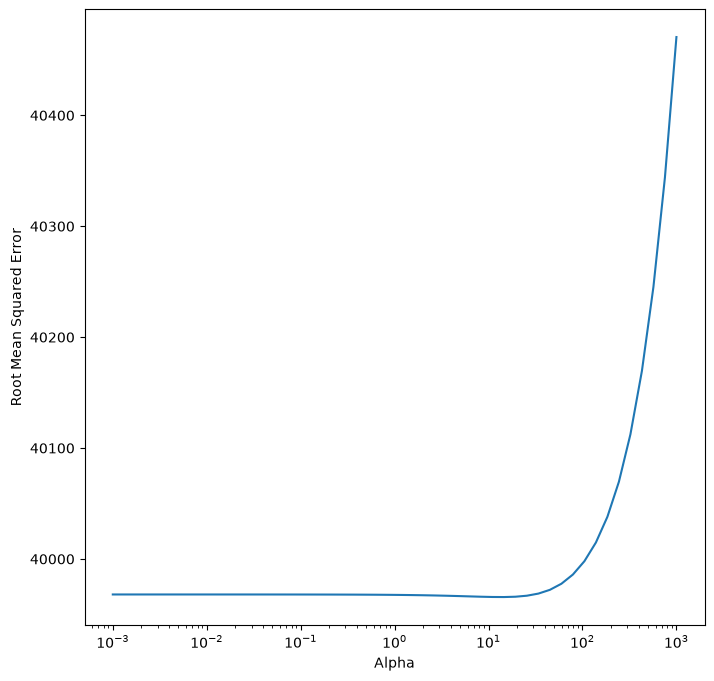

The best alpha value is 14.563 which gives a testing root mean squared error of 38528.027 and testing R squared score of 0.296.


,value
variable,
job_title_short_Senior Data Scientist,21392.996021
job_country_South Africa,14993.387277
job_country_United States,13777.577715
job_title_short_Senior Data Engineer,13356.285796
job_country_Sudan,11037.739569
job_via_LinkedIn,10830.828341
job_via_Built In,10345.071280
job_title_short_Software Engineer,8848.064780
job_title_short_Machine Learning Engineer,8579.888734


The model with only job titles as predictors has a root mean squared error of 41242.045 and an R squared score of 0.194.


,value
variable,
job_title_short_Senior Data Scientist,28899.168855
job_title_short_Senior Data Engineer,22715.739562
job_title_short_Machine Learning Engineer,9009.227700
job_title_short_Data Scientist,8686.772279
job_title_short_Data Engineer,5862.177818
job_title_short_Software Engineer,3801.748518
job_title_short_Cloud Engineer,-5220.839995
job_title_short_Senior Data Analyst,-12269.425017
job_title_short_Business Analyst,-29508.508607


The model with only skills as predictors has a root mean squared error of 42277.895 and an R squared score of 0.153.


...

,value
variable,
job_country_South Africa,16529.304259
job_country_Sudan,16397.713985
job_country_Canada,10366.064521
job_country_United States,6239.131087
job_country_Germany,-1342.283100
job_country_United Kingdom,-2938.613024
job_country_other,-6021.973551
job_country_Spain,-7230.333938
job_country_Poland,-10095.737311


The model with only the websites as predictors has a root mean squared error of 44696.273 and an R squared score of 0.053.


,value
variable,
job_via_Built In,25525.358815
job_via_Talent.com,13817.900139
job_via_LinkedIn,13176.297809
job_via_Ladders,4767.208908
job_via_other,2928.872445
job_via_Dice,-716.743063
job_via_Ai-Jobs.net,-6311.984726
job_via_ZipRecruiter,-8744.849676
job_via_Indeed,-9550.847518


The model with only other stuff as predictors has a root mean squared error of 45476.255 and an R squared score of 0.020.


,value
variable,
job_health_insurance,10352.124025
job_work_from_home,10087.550401
job_posted_month_sine,-204.947196
job_posted_year,-4517.705409
job_no_degree_mention,-4940.669336


In [40]:
print(f'The mean, median, and standard deviation of the salary are {np.mean(y):.3f}, {np.median(y):.3f}, and {np.std(y):.3f} respectively.')

alphas = np.logspace(-3, 3, 50)
rmses = {}
for alpha in alphas:
    rmses_one_fold = []
    for fold in mlm.kfold_cross_validation(5, X_training.shape[0]):
        inner_model = mlm.Ridge_Regression()
        inner_model.fit(np.delete(X_training, fold, axis=0), np.delete(y_training, fold, axis=0), alpha=alpha)
        predictions = inner_model.predict(X_training[fold])
        rmse = np.sqrt(np.mean((y_training[fold] - predictions)**2))
        rmses_one_fold.append(rmse)
    average_rmse = np.mean(rmses_one_fold)
    rmses.update({alpha:average_rmse})
best_alpha = min(rmses, key=rmses.get)

fig, ax = plt.subplots(figsize=(8,8))
ax.semilogx(rmses.keys(), rmses.values())
ax.set_xlabel('Alpha')
ax.set_ylabel('Root Mean Squared Error')
plt.show()

final_model = mlm.Ridge_Regression()
final_model.fit(X_training, y_training, alpha=best_alpha)
predictions = final_model.predict(X_testing)
rmse = np.sqrt(np.mean((y_testing - predictions)**2))
r2 = 1 - (np.sum((y_testing - predictions)**2)) / (np.sum((y_testing - np.mean(y_testing))**2))

print(f'The best alpha value is {best_alpha:.3f} which gives a testing root mean squared error of {rmse:.3f} and testing R squared score of {r2:.3f}.')
full_model = mlm.Ridge_Regression()
full_model.fit(X, y, alpha=best_alpha)
parameters = predictors
parameters_dictionary = dict(zip(parameters, full_model.parameters))
parameters_df = pd.DataFrame(parameters_dictionary)
parameters_df = pd.melt(parameters_df).set_index('variable', drop=True).sort_values(by='value', ascending=False)
display(parameters_df)

def separate_by_category(inputted_string=None, inputted_list=None):
    if not inputted_list:
        specific_predictors = [x for x in parameters_dictionary.keys() if inputted_string in x]
    if not inputted_string:
        specific_predictors = inputted_list
    specific_model = mlm.Ridge_Regression()
    specific_X = df[specific_predictors].to_numpy()
    specific_model.fit(specific_X, y, best_alpha)
    specific_parameters = specific_predictors
    specific_parameters_dictionary = dict(zip(specific_parameters, specific_model.parameters))
    parameters_specific_df = pd.DataFrame(specific_parameters_dictionary)
    parameters_specific_df = pd.melt(parameters_specific_df).set_index('variable', drop=True)
    evaluation_model = mlm.Ridge_Regression()
    evaluation_model.fit(specific_X[training_index], y[training_index], alpha=best_alpha)
    predictions = evaluation_model.predict(specific_X[testing_index])
    rmse = np.sqrt(np.mean((y_testing - predictions)**2))
    r2 = 1 - (np.sum((y_testing - predictions)**2)) / (np.sum((y_testing - np.mean(y_testing))**2))
    return parameters_specific_df.sort_values(by='value', ascending=False), rmse, r2

parameters_specific_job_title_df, rmse_job_title, r2_job_title = separate_by_category(inputted_string='job_title_short')
print(f'The model with only job titles as predictors has a root mean squared error of {rmse_job_title:.3f} and an R squared score of {r2_job_title:.3f}.')
display(parameters_specific_job_title_df)

parameters_specific_skill_df, rmse_skill, r2_skill  = separate_by_category(inputted_string='skill')
print(f'The model with only skills as predictors has a root mean squared error of {rmse_skill:.3f} and an R squared score of {r2_skill:.3f}.')
display(parameters_specific_skill_df)

job_schedule_types = ['Contractor', 'Full-time', 'Internship', 'Part-time', 'Tempwork']
parameters_specific_schedule_df, rmse_schedule, r2_schedule  = separate_by_category(inputted_list=job_schedule_types)
print(f'The model with only job schedule types as predictors has a root mean squared error of {rmse_schedule:.3f} and an R squared score of {r2_schedule:.3f}.')
display(parameters_specific_schedule_df)

parameters_specific_country_df, rmse_country, r2_country  = separate_by_category(inputted_string='job_country')
print(f'The model with only countries as predictors has a root mean squared error of {rmse_country:.3f} and an R squared score of {r2_country:.3f}.')
display(parameters_specific_country_df)

parameters_specific_via_df, rmse_via, r2_via  = separate_by_category(inputted_string='job_via')
print(f'The model with only the websites as predictors has a root mean squared error of {rmse_via:.3f} and an R squared score of {r2_via:.3f}.')
display(parameters_specific_via_df)

misc = ['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance', 'job_posted_year', 'job_posted_month_sine']
parameters_specific_misc_df, rmse_misc, r2_misc = separate_by_category(inputted_list=misc)
print(f'The model with only other stuff as predictors has a root mean squared error of {rmse_misc:.3f} and an R squared score of {r2_misc:.3f}.')
display(parameters_specific_misc_df)

Here, ridge regression is used. The target variable is salary. The main reason ridge regression was used here was so that I could keep all of the dummy variables. The value for the shrinkage parameter was chosen using cross validation based on which value reduces the RMSE the most. Then, the value for the shrinkage parameter that was chosen was 14.563, both the RMSE and R squared score were calculated to 3 decimal places which were 38528.027 and 0.296 respectively.

The parameters from the regression are also quite sensible. Senior data scientist has the highest coefficient of 21393 while internship has the lowest at -37963. Skills like excel which are more common in entry level positions have large negative coefficients such as -12037 while skills like pytorch which are in more technical positions have large positive coefficients such as 7249. The country and the website the job was posted also affect the salary.

For the smaller models which are mostly based on one category, the RMSE and R squared scores are:
- Job Title - 41242.045 and 0.194
- Skills - 42277.895 and 0.153
- Schedule Type - 45542.618 and 0.017
- Country - 45554.369 and 0.016
- Website - 44696.273 and 0.053
- Miscellaneous - 45476.255 and 0.020

Unsurprisingly, job title and skills take the lead here. Country, Schedule type, and miscellaneous all have very low predictive power on their own while website is somewhere around the middle. Schedule type not having much predictive power is expected as over 97% of the job postings are full-time. In skills, python has the highest coefficient beating out pytorch even though the latter had a higher coefficient in the larger model. The explanation I think makes the most sense is that python is commonly found in technical roles so most of its effect was absorbed by the job titles. Pytorch is a more uncommon skill overall so it got to keep more of its effect. Excel still has the lowest coefficient at -20267. The job title coefficients are as expected with senior data scientist with the highest one at 28899 and data analyst with the lowest one of -31976.

Adding all of the predictors into one model decreases RMSE and increases R squared. In the full model, there definitely is an improvement as the standard deviation is 47019.486 and the RMSE of 38528.027 is quite a bit less than that. However, the R squared in the full model isn't too high and the RMSE still makes up a significant fraction of the standard deviation. Salary data especially for job posting is extremely noisy and there are probably a lot more predictors we did not take into account. Additionally, all of the predictors are linear so the R squared might be low if there are nonlinearities this model is not able to capture.